## Parallel Graph


#### NOTE on State for parallel branches:

- Each branch writes to a DIFFERENT key in state.
- We combine them in the merge node.


In [16]:
from typing import TypedDict


# --- 1. STATE ---
class State(TypedDict):
    product_name: str
    price_result: str  # written by price_branch
    review_result: str  # written by review_branch
    stock_result: str  # written by stock_branch
    final_summary: str  # written by merge_node

In [17]:
import time


# --- 2. NODES ---
def price_branch(state: State) -> dict:
    time.sleep(0.1)  # simulate external API call
    result = f"Price of '{state['product_name']}': ₹4,999"
    print(f"[price]  Done → {result}\n")
    return {"price_result": result}


def review_branch(state: State) -> dict:
    time.sleep(0.1)
    result = f"Reviews of '{state['product_name']}': 4.3⭐ (1,240 reviews)"
    print(f"[review] Done → {result}\n")
    return {"review_result": result}


def stock_branch(state: State) -> dict:
    time.sleep(0.1)
    result = f"Stock of '{state['product_name']}': In Stock ✅ (42 units left)"
    print(f"[stock]  Done → {result}\n")
    return {"stock_result": result}


def merge_node(state: State) -> dict:
    """Fan-in: all 3 branches are complete when this runs"""
    summary = (
        f"📦 Product Report for: {state['product_name']}\n"
        f"  💰 {state['price_result']}\n"
        f"  ⭐ {state['review_result']}\n"
        f"  📦 {state['stock_result']}"
    )
    print(f"[merge]  All branches complete. Building summary.")
    return {"final_summary": summary}

In [18]:
from langgraph.graph import StateGraph, START, END


# --- 3. GRAPH CONSTRUCTION ---
builder = StateGraph(State)

builder.add_node("price", price_branch)
builder.add_node("review", review_branch)
builder.add_node("stock", stock_branch)
builder.add_node("merge", merge_node)

# START → all 3 branches simultaneously (fan-out)
builder.add_edge(START, "price")
builder.add_edge(START, "review")
builder.add_edge(START, "stock")

# All 3 branches → merge (fan-in)
# LangGraph waits for ALL of them before running merge
builder.add_edge("price", "merge")
builder.add_edge("review", "merge")
builder.add_edge("stock", "merge")

builder.add_edge("merge", END)

graph = builder.compile()

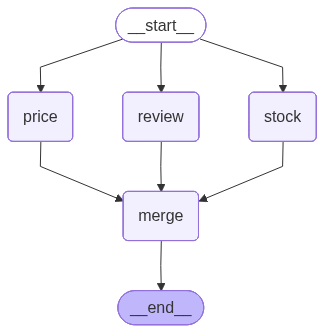

In [19]:
# --- 4. VISUALIZE ---
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
# --- 5. RUN & TEST ---
result = graph.invoke(
    {
        "product_name": "LangGraph Pro Laptop",
        "price_result": "",
        "review_result": "",
        "stock_result": "",
        "final_summary": "",
    }
)
print("\n" + result["final_summary"])

[price]  Done → Price of 'LangGraph Pro Laptop': ₹4,999

[review] Done → Reviews of 'LangGraph Pro Laptop': 4.3⭐ (1,240 reviews)

[stock]  Done → Stock of 'LangGraph Pro Laptop': In Stock ✅ (42 units left)

[merge]  All branches complete. Building summary.

📦 Product Report for: LangGraph Pro Laptop
  💰 Price of 'LangGraph Pro Laptop': ₹4,999
  ⭐ Reviews of 'LangGraph Pro Laptop': 4.3⭐ (1,240 reviews)
  📦 Stock of 'LangGraph Pro Laptop': In Stock ✅ (42 units left)
